# Bank Loan Analysis

### Business Problem
Banks managing large loan portfolios lack a unified view of portfolio health, making it difficult to act before problems escalate. Without real-time monitoring, rising defaults go undetected and recovery becomes costly. Weak underwriting compounds the issue, as risky borrowers are approved rather than declined, leading to higher charge-off rates and revenue loss. Concentration risk is also a concern when lending is heavily skewed toward a single purpose or long-term loan tenures, both of which are sensitive to economic downturns. Add to this uneven regional performance and no loan-level audit trail, and banks are left making slow, reactive decisions with limited accountability across teams

### Objective 
* To monitor and track key loan portfolio metrics including funded amounts, repayment figures, interest rates, and DTI ratios on a monthly basis.
* To provide a clear distinction between good loans and bad loans for effective credit risk assessment and portfolio quality evaluation.
* To analyze loan repayment behavior across various loan status classifications to identify potential defaults and recovery trends.
* To support management and stakeholders in making informed, data-driven lending decisions through a centralized and real-time view.
* To enable proactive portfolio management, early risk detection, and ensure regulatory compliance across all loan segments

####  Tool - Python( used for):

•	Data cleaning

•	Data preprocessing

•	Exploratory Data Analysis (EDA)

•	Data visualization

•	Business insight generation


In [1]:
## Importing liabraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [2]:
###  Importing the dataset

Bank_df = pd.read_csv("C:/Users/charp/OneDrive/Desktop/Data Analytics projects/Bank Loan Monitoring Project/financial_loan.csv")

Bank_df

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,11-07-2021,16-05-2021,16-05-2021,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,11-10-2021,16-04-2021,16-05-2021,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,11-09-2021,16-05-2021,16-05-2021,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,11-10-2021,16-05-2021,16-05-2021,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [3]:
Bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

In [4]:
Bank_df.isnull().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

In [5]:
Bank_df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


# MetaData of Data

In [6]:
print("No of Rows:", Bank_df.shape[0])

No of Rows: 38576


In [7]:
print("No of columns:", Bank_df.shape[1])

No of columns: 24


In [8]:
Bank_df.dtypes

id                         int64
address_state             object
application_type          object
emp_length                object
emp_title                 object
grade                     object
home_ownership            object
issue_date                object
last_credit_pull_date     object
last_payment_date         object
loan_status               object
next_payment_date         object
member_id                  int64
purpose                   object
sub_grade                 object
term                      object
verification_status       object
annual_income            float64
dti                      float64
installment              float64
int_rate                 float64
loan_amount                int64
total_acc                  int64
total_payment              int64
dtype: object

In [9]:
# Converting date column  object to date time

bank_col = ['issue_date','last_credit_pull_date','last_payment_date','next_payment_date']

# converting all columns at once

for col in bank_col:
    Bank_df[col] = pd.to_datetime(Bank_df[col], format = 'mixed', dayfirst = True, errors = 'coerce') 

print(Bank_df.dtypes)

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object


In [10]:
Bank_df[bank_col].isna().sum()

issue_date               0
last_credit_pull_date    0
last_payment_date        0
next_payment_date        0
dtype: int64

## Total Loan Application

In [11]:
Total_loan_application = Bank_df['id'].count()

print("Total Loan Application :", Total_loan_application)

Total Loan Application : 38576


### MTD Total loan Application

In [12]:
# clean dataframe ignoring missing dates
clean_df = Bank_df[Bank_df['issue_date'].notna()]

latest_issue_date = clean_df['issue_date'].max()
latest_month = latest_issue_date.month
latest_year = latest_issue_date.year

mtd_data = clean_df[(clean_df['issue_date'].dt.year == latest_year) & (clean_df['issue_date'].dt.month == latest_month)]

mtd_loan_application = mtd_data['id'].count()

print(f"MTD Loan Application(for {latest_issue_date.strftime('%B %Y')}):{mtd_loan_application}")
    

MTD Loan Application(for December 2021):4314


### Total Funded Amount

In [13]:
total_funded_amount = Bank_df['loan_amount'].sum()
total_funded_amount_million = total_funded_amount / 1000000
print("Total Funded Amount:{:.2f}M" .format(total_funded_amount_million))

Total Funded Amount:435.76M


### MTD Total Funded Amount

In [14]:
latest_issue_date = Bank_df['issue_date'].max()
latest_month = latest_issue_date.month
latest_year = latest_issue_date.year

mtd_data = Bank_df[(Bank_df['issue_date'].dt.year == latest_year) & (Bank_df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount / 1000000

print("MTD Total Funded Amount:{:.2f}M" .format(mtd_total_funded_amount_millions))   

MTD Total Funded Amount:53.98M


### Total Amount Recived

In [15]:
total_amount_received = Bank_df['total_payment'].sum()
total__amount_received_million = total_amount_received / 1000000
print("Total Amount Received :{:.2f}M" .format(total__amount_received_million))

Total Amount Received :473.07M


### MTD Total Amount Recived

In [16]:
latest_issue_date = Bank_df['issue_date'].max()
latest_month = latest_issue_date.month
latest_year = latest_issue_date.year

mtd_data = Bank_df[(Bank_df['issue_date'].dt.year == latest_year) & (Bank_df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received = mtd_total_amount_received / 1000000

print("MTD Total Amount Received :{:.2f}M" .format(mtd_total_amount_received))   

MTD Total Amount Received :58.07M


### Average intrest rate

In [17]:
avg_int_rate = Bank_df['int_rate'].mean()*100
print("Averag Intrest Rate:{:.2f}%".format(avg_int_rate))

Averag Intrest Rate:12.05%


### Average Debt to income Ratio(DTI)

In [18]:
Average_DTI = Bank_df['dti'].mean()*100
print("Average DTI:{:.2f}%".format(Average_DTI))

Average DTI:13.33%


### Good Loan Metrics

In [19]:
good_loans = Bank_df[Bank_df['loan_status'].isin(["Fully Paid","Current"])]
total_loan_application = Bank_df['id'].count()
good_loan_application = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_application / total_loan_application)* 100

print("Good Loan Application :", good_loan_application)
print("Good Loan Funded Amount :{:.2f}M" .format(good_loan_funded_amount_millions))
print("Good Loan Total Received Amount :{: .2f}M" .format(good_loan_received_millions))
print("Percentage of Good Loan Application : {: .2f}%" .format(good_loan_percentage))

Good Loan Application : 33243
Good Loan Funded Amount :370.22M
Good Loan Total Received Amount : 435.79M
Percentage of Good Loan Application :  86.18%


### Bad Loan Metrics

In [20]:
Bad_loans = Bank_df[Bank_df['loan_status'].isin(["Charged Off"])]
total_loan_application = Bank_df['id'].count()
Bad_loan_application = Bad_loans['id'].count()
Bad_loan_funded_amount = Bad_loans['loan_amount'].sum()
Bad_loan_received = Bad_loans['total_payment'].sum()

Bad_loan_funded_amount_millions = Bad_loan_funded_amount / 1000000
Bad_loan_received_millions = Bad_loan_received / 1000000

Bad_loan_percentage = (Bad_loan_application / total_loan_application)* 100

print("Bad Loan Application :", Bad_loan_application)
print("Bad Loan Funded Amount :{:.2f}M" .format(Bad_loan_funded_amount_millions))
print("Bad Loan Total Received Amount :{: .2f}M" .format(Bad_loan_received_millions))
print("Percentage of Bad Loan Application : {: .2f}%" .format(Bad_loan_percentage))

Bad Loan Application : 5333
Bad Loan Funded Amount :65.53M
Bad Loan Total Received Amount : 37.28M
Percentage of Bad Loan Application :  13.82%


### Monthly Trend by issue Date For Total Funded Amount

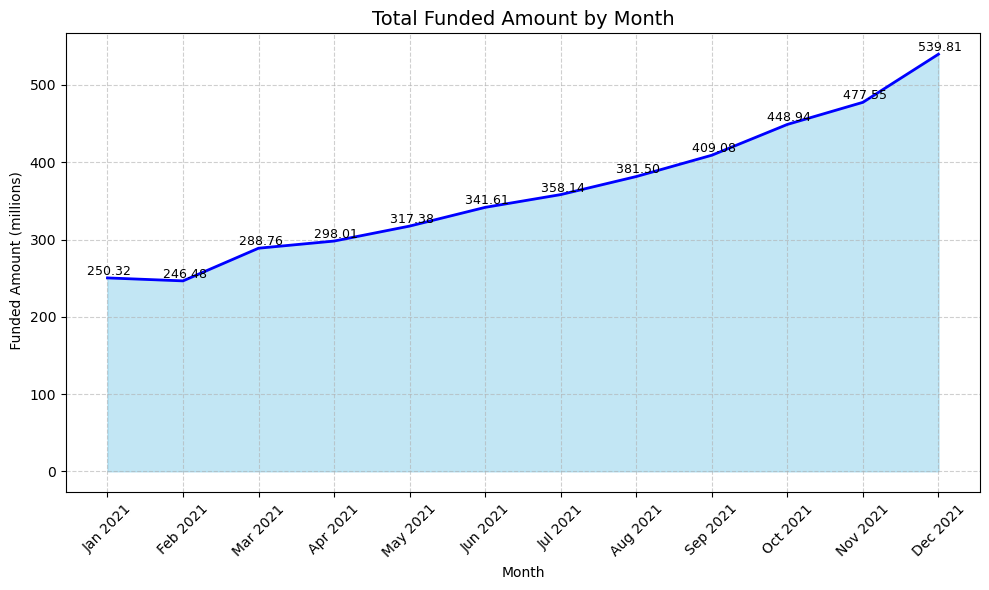

In [22]:
monthly_funded = (
    Bank_df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['loan_amount']
    .sum()
    .div(1_00_000)
    .reset_index(name = 'loan_amount_millions')
)

plt.figure(figsize = (10,6))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color = 'skyblue', alpha = 0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color ='blue', linewidth =2)

for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']: .2f}",
             ha = 'center', va = 'bottom', fontsize = 9, rotation = 0, color ='black')

plt.title('Total Funded Amount by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel(' Funded Amount (millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels = monthly_funded['month_name'], rotation = 45)
plt.grid(True, linestyle= '--',alpha = 0.6)
plt.tight_layout()
plt.show()

### Monthly Trend by issue Date For Total Amount Received

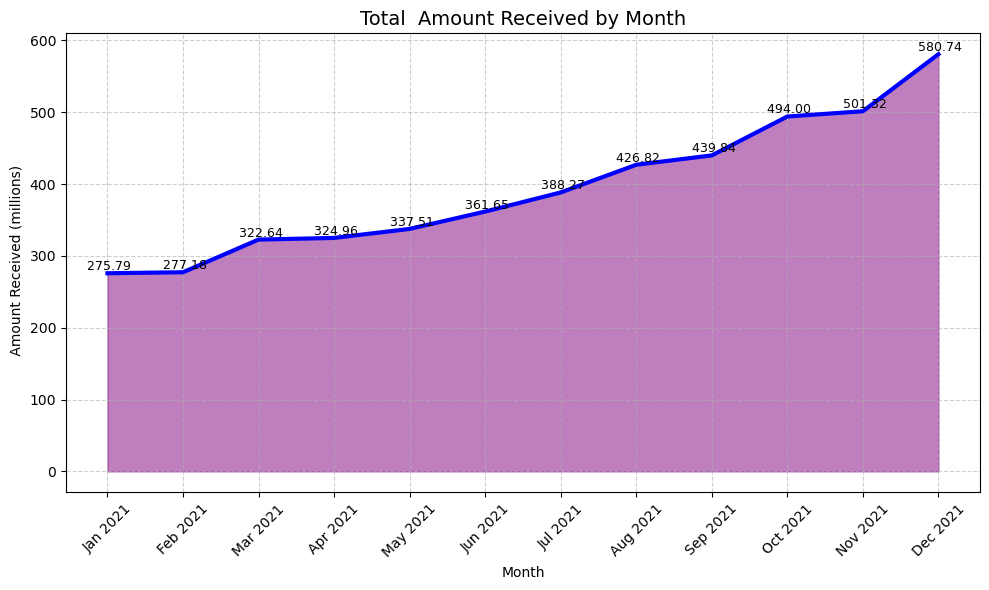

In [35]:
monthly_Amount_Received = (
    Bank_df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['total_payment']
    .sum()
    .div(100000)
    .reset_index(name = 'amount_Received_millions')
)

plt.figure(figsize = (10,6))
plt.fill_between(monthly_Amount_Received['month_name'],monthly_Amount_Received['amount_Received_millions'],color = 'purple', alpha = 0.5)
plt.plot(monthly_Amount_Received['month_name'],monthly_Amount_Received['amount_Received_millions'],color ='blue', linewidth = 3)

for i, row in monthly_Amount_Received.iterrows():
    plt.text(i, row['amount_Received_millions'] + 0.1, f"{row['amount_Received_millions']: .2f}",
             ha = 'center', va = 'bottom', fontsize = 9, rotation = 0, color ='black')

plt.title('Total  Amount Received by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel(' Amount Received (millions)')
plt.xticks(ticks=range(len(monthly_Amount_Received)), labels = monthly_Amount_Received['month_name'], rotation = 45)
plt.grid(True, linestyle= '--',alpha = 0.6)
plt.tight_layout()
plt.show()

### Monthly Trend by issue Date For Total Loan Applications

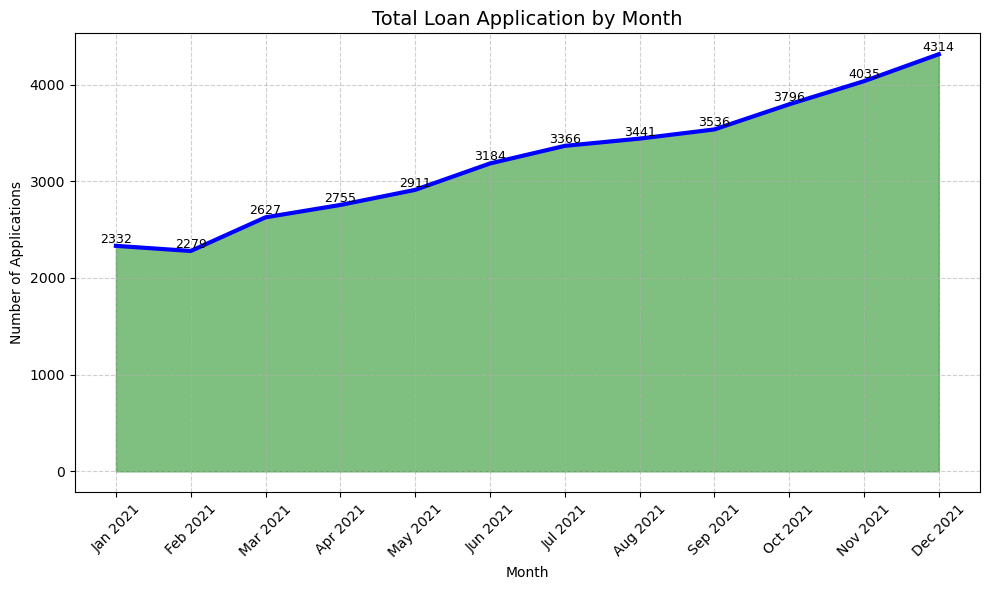

In [31]:
monthly_Loan_Application = (
    Bank_df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['id']
    .count()
    .reset_index(name = 'Loan_application_count')
)

plt.figure(figsize = (10,6))
plt.fill_between(monthly_Loan_Application['month_name'],monthly_Loan_Application['Loan_application_count'],color = 'green', alpha = 0.5)
plt.plot(monthly_Loan_Application['month_name'],monthly_Loan_Application['Loan_application_count'],color ='blue', linewidth = 3)

for i, row in monthly_Loan_Application.iterrows():
    plt.text(i, row['Loan_application_count'] + 0.5, f"{row['Loan_application_count']}",
             ha = 'center', va = 'bottom', fontsize = 9, rotation = 0, color ='black')

plt.title('Total Loan Application by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_Loan_Application)), labels = monthly_Loan_Application['month_name'], rotation = 45)
plt.grid(True, linestyle= '--',alpha = 0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

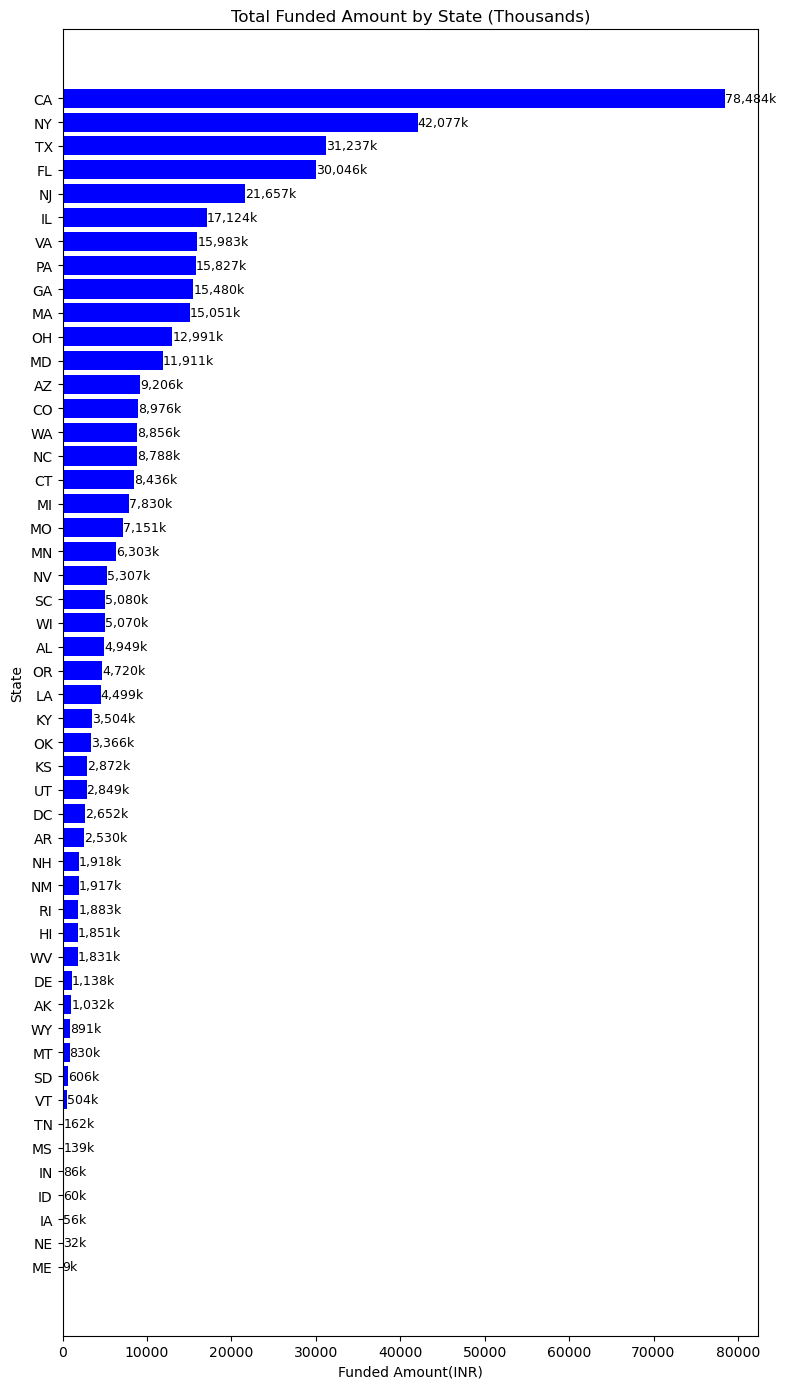

In [38]:
state_funding = Bank_df.groupby('address_state')['loan_amount'].sum().sort_values(ascending = True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(8,14))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'blue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}k', va = 'center', fontsize = 9)

plt.title('Total Funded Amount by State (Thousands)')
plt.xlabel('Funded Amount(INR)')
plt.ylabel('State')
plt.tight_layout()
plt.show()


### Regional Analysis by State for Total Amount Received

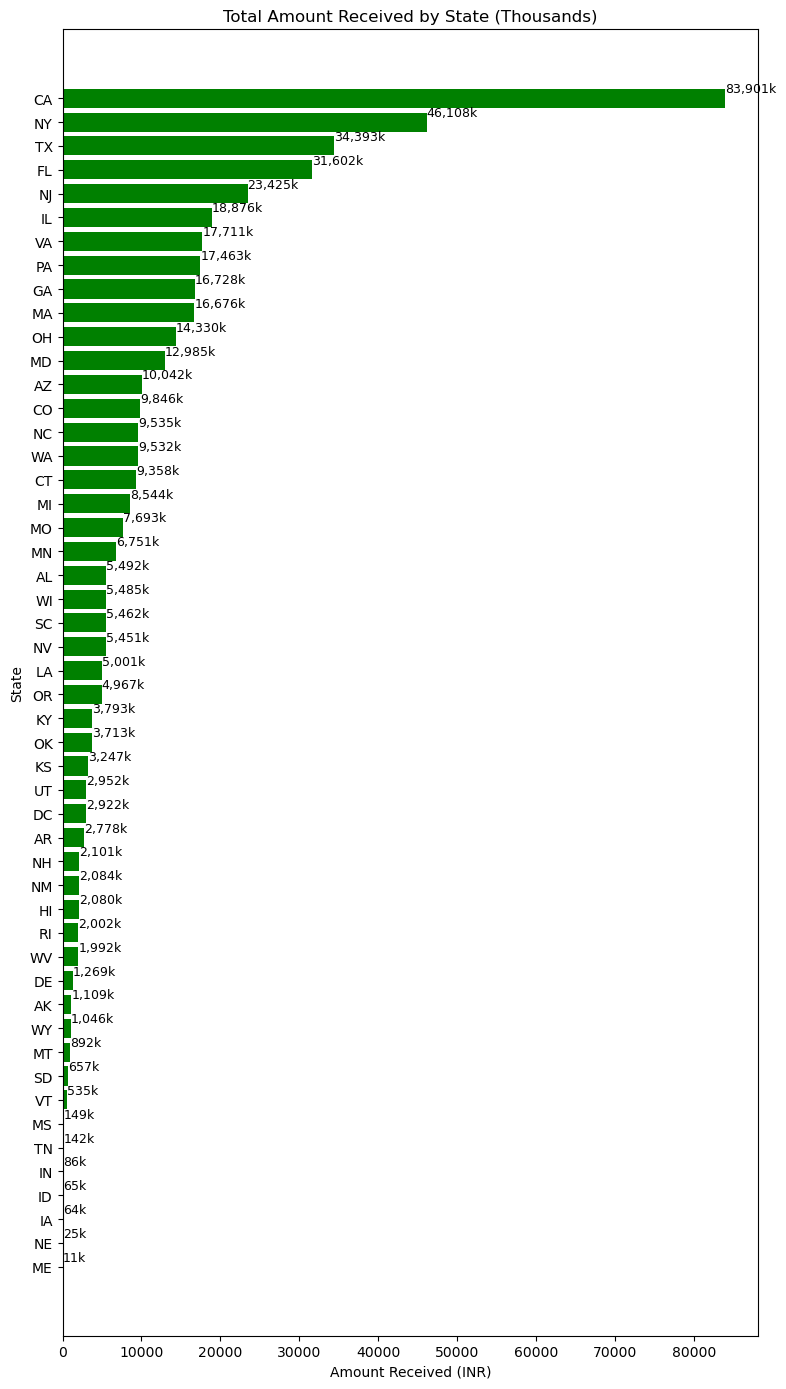

In [36]:
state_funding = Bank_df.groupby('address_state')['total_payment'].sum().sort_values(ascending = True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(8,14))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'green')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height(),
            f'{width:,.0f}k', va = 'center', fontsize = 9)

plt.title('Total Amount Received by State (Thousands)')
plt.xlabel('Amount Received (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total loan Applications

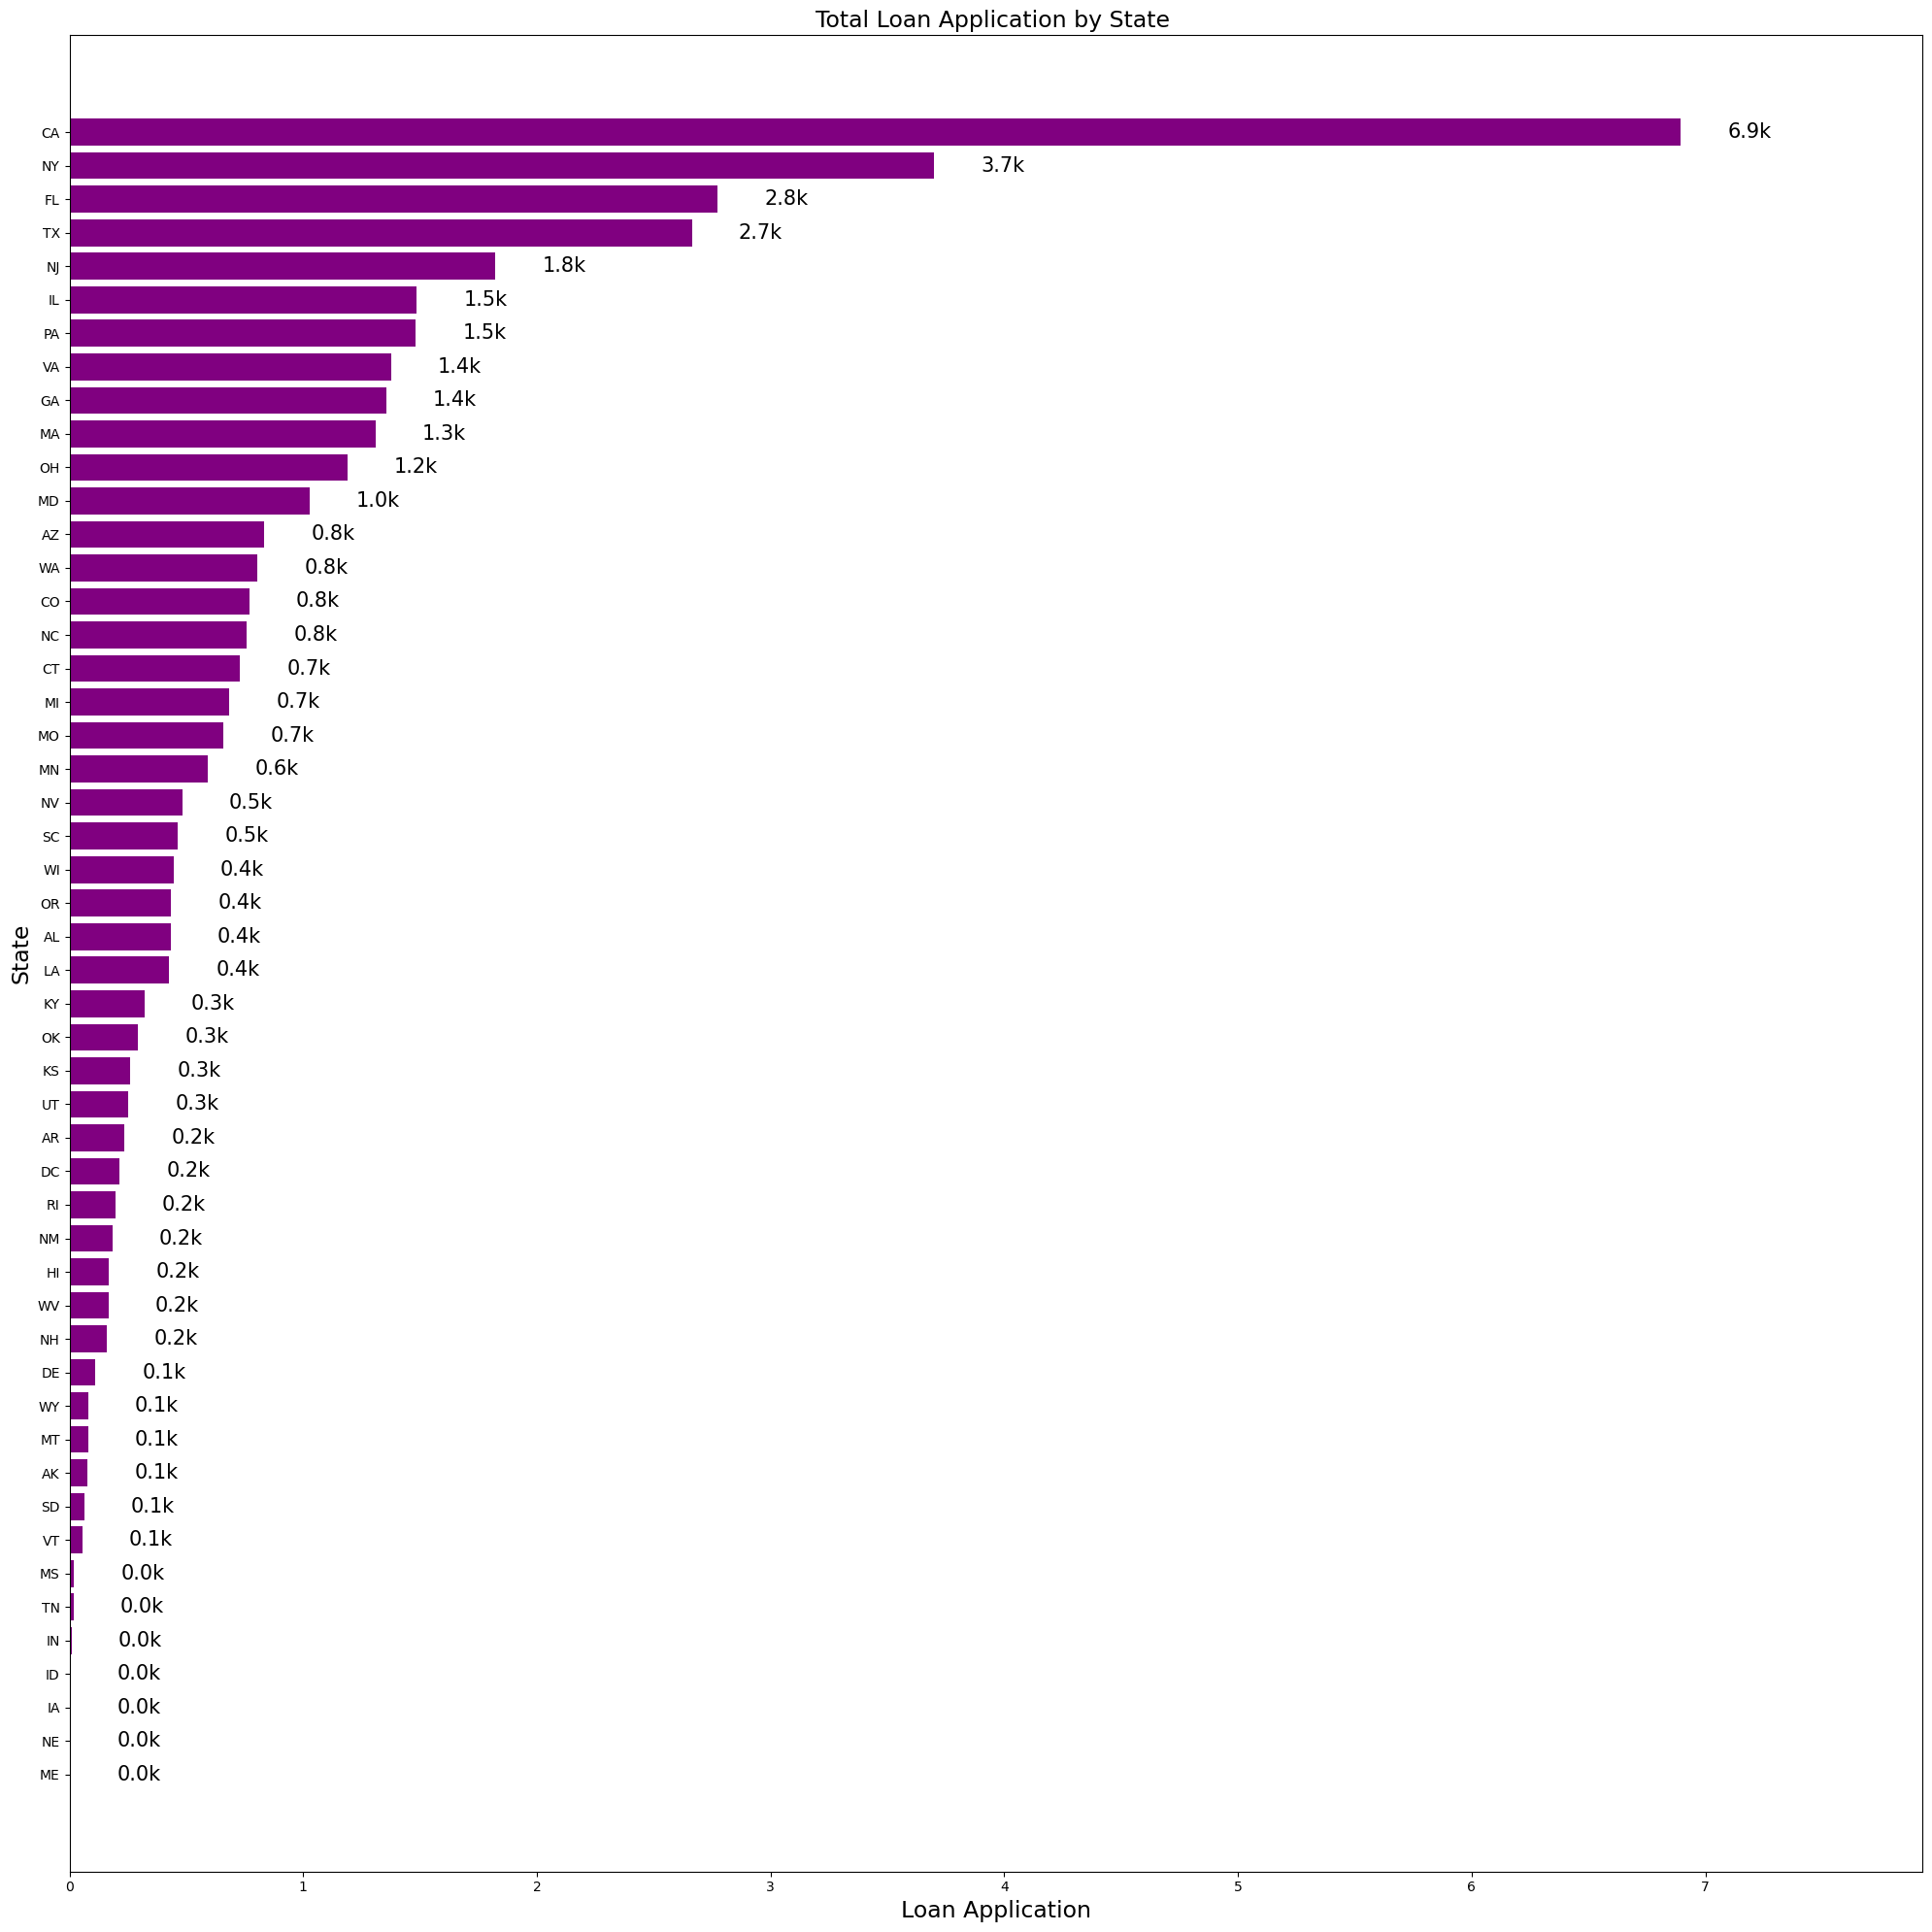

In [41]:
state_Application = Bank_df.groupby('address_state')['id'].count().sort_values(ascending = True)
state_Application_thousands = state_Application / 1000

plt.figure(figsize=(20,20))
bars = plt.barh(state_Application_thousands.index, state_Application_thousands.values, color = 'purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            f'{width:,.1f}k', va = 'center', fontsize = 15)

plt.title('Total Loan Application by State ', fontsize = 17)
plt.xlabel('Loan Application',fontsize = 17)
plt.ylabel('State',fontsize = 17)
plt.xlim(0, state_Application_thousands.max() * 1.15)
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

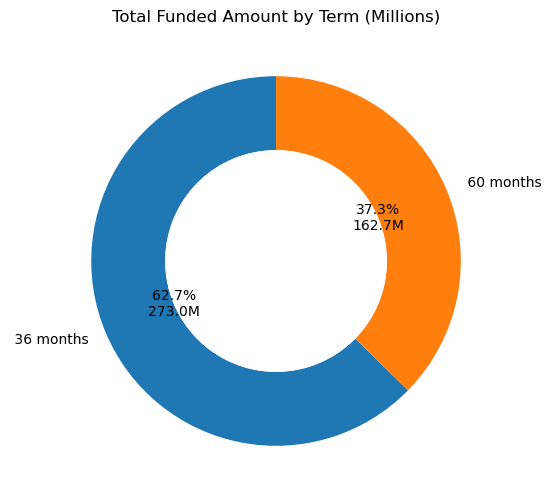

In [61]:
from matplotlib.patches import Circle

term_funding_millions = (Bank_df.groupby('term')['loan_amount'].sum()/1000000)

plt.figure(figsize=(6,6))
plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n{p*term_funding_millions.sum()/100:.1f}M",
    startangle = 90,
    wedgeprops = {'width': 0.4}
)
centre_circle = Circle((0,0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Total Funded Amount by Term (Millions)")
plt.show()

### Loan Term Analysis by Total Amount Received

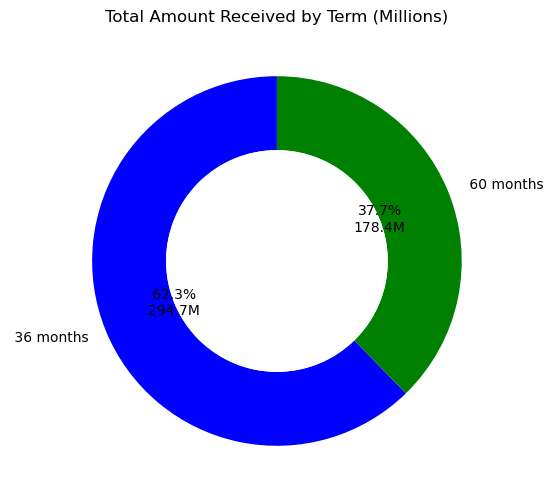

In [60]:
from matplotlib.patches import Circle

term_Amt_Recived_millions = (Bank_df.groupby('term')['total_payment'].sum()/1000000)

plt.figure(figsize=(6,6))
plt.pie(
    term_Amt_Recived_millions,
    labels = term_Amt_Recived_millions.index,
    colors = ['blue','green'],
    autopct=lambda p: f"{p:.1f}%\n{p*term_Amt_Recived_millions.sum()/100:.1f}M",
    startangle = 90,
    wedgeprops = {'width': 0.4}
)
centre_circle = Circle((0,0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Total Amount Received by Term (Millions)")
plt.show()

### Loan Term Analysis by Total Loan Application

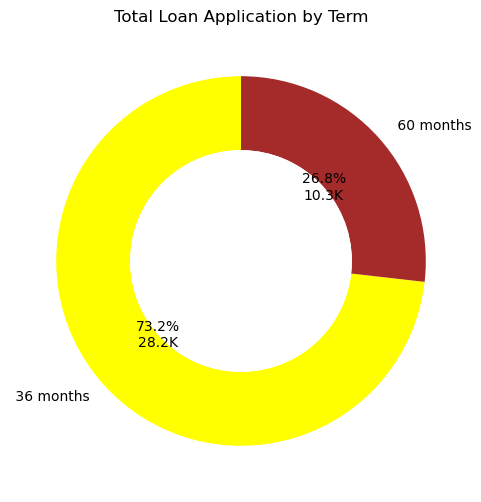

In [69]:
from matplotlib.patches import Circle

term_loan_app = (Bank_df.groupby('term')['id'].count()/10000)

plt.figure(figsize=(6,6))
plt.pie(
    term_loan_app,
    labels = term_loan_app.index,
    colors = ['yellow','brown'],
    autopct=lambda p: f"{p:.1f}%\n{p*term_loan_app.sum()/10:.1f}K",
    startangle = 90,
    wedgeprops = {'width': 0.4}
)
centre_circle = Circle((0,0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)
plt.title("Total Loan Application by Term")
plt.show()

### Employee Length by Total Funded Amount

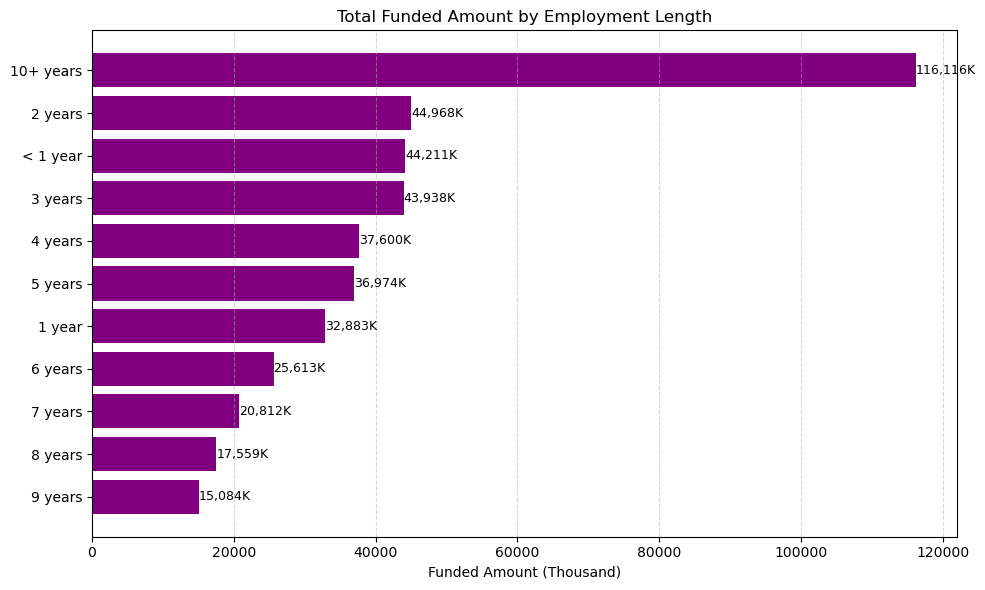

In [72]:
emp_funding = Bank_df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize = (10,6))
bars = plt.barh(emp_funding.index, emp_funding, color ='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() /2,
            f"{width:,.0f}K", va = 'center', fontsize = 9)

plt.xlabel("Funded Amount (Thousand)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis = 'x', linestyle ='--', alpha = 0.5)
plt.tight_layout()
plt.show()

### Employee Length by Total Amount Received

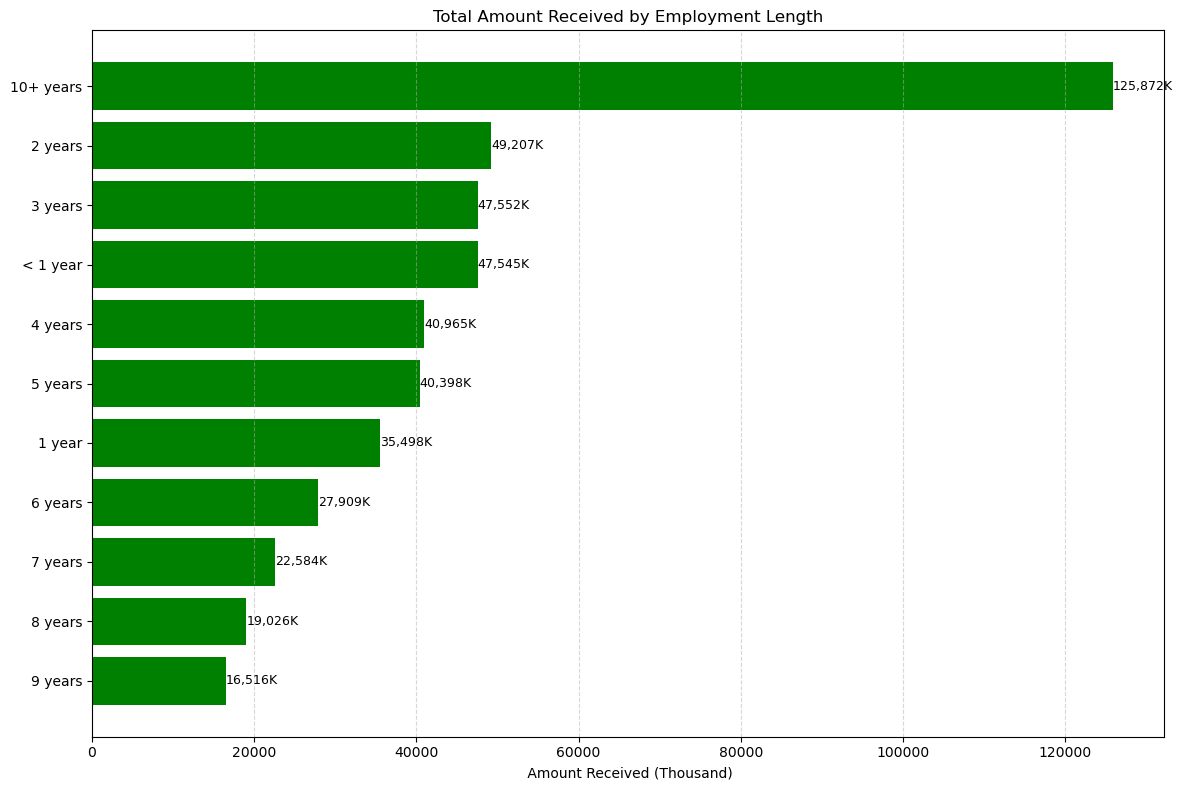

In [78]:
emp_Amt_Received = Bank_df.groupby('emp_length')['total_payment'].sum().sort_values()/1000

plt.figure(figsize = (12,8))
bars = plt.barh(emp_Amt_Received.index, emp_Amt_Received, color ='green')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height() /2,
            f"{width:,.0f}K", va = 'center', fontsize = 9)

plt.xlabel(" Amount Received (Thousand)")
plt.title("Total Amount Received by Employment Length")
plt.grid(axis = 'x', linestyle ='--', alpha = 0.5)
plt.tight_layout()
plt.show()

### Employee Length by Total loan Application

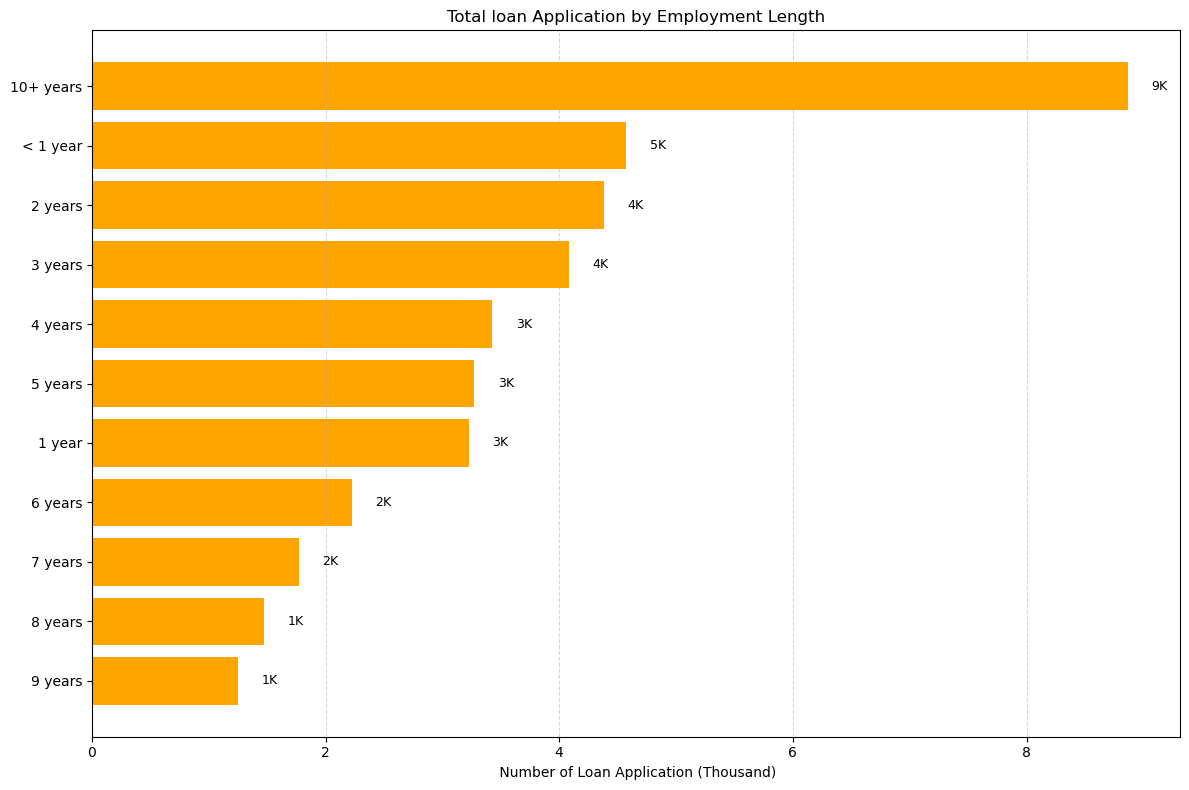

In [79]:
emp_loan_application = Bank_df.groupby('emp_length')['id'].count().sort_values()/1000

plt.figure(figsize = (12,8))
bars = plt.barh(emp_loan_application.index, emp_loan_application, color ='orange')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height() /2,
            f"{width:,.0f}K", va = 'center', fontsize = 9)

plt.xlabel(" Number of Loan Application (Thousand)")
plt.title("Total loan Application by Employment Length")
plt.grid(axis = 'x', linestyle ='--', alpha = 0.5)
plt.tight_layout()
plt.show()

### Employee purpose by Total funded amount

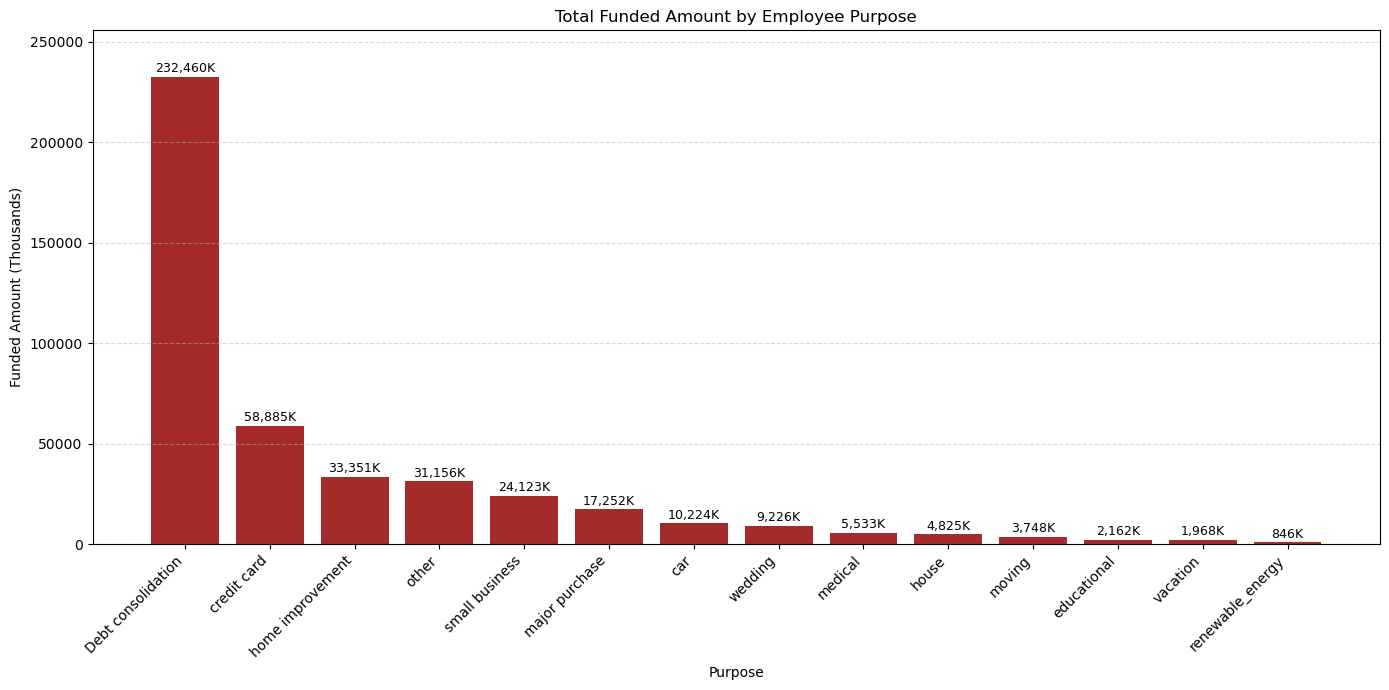

In [87]:
emp_funding = Bank_df.groupby('purpose')['loan_amount'].sum().sort_values(ascending=False)/1000

plt.figure(figsize = (14,7))
bars = plt.bar(emp_funding.index, emp_funding.values, color ='brown')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() /2, height + emp_funding.max() * 0.01,
            f"{height:,.0f}K", ha = 'center', fontsize = 9)

plt.title("Total Funded Amount by Employee Purpose")
plt.xlabel("Purpose")
plt.ylabel("Funded Amount (Thousands)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis = 'y', linestyle ='--', alpha = 0.5,)
plt.ylim(0, emp_funding.max() * 1.10)

plt.tight_layout()
plt.show()

### Employee purpose by Total Amount Received

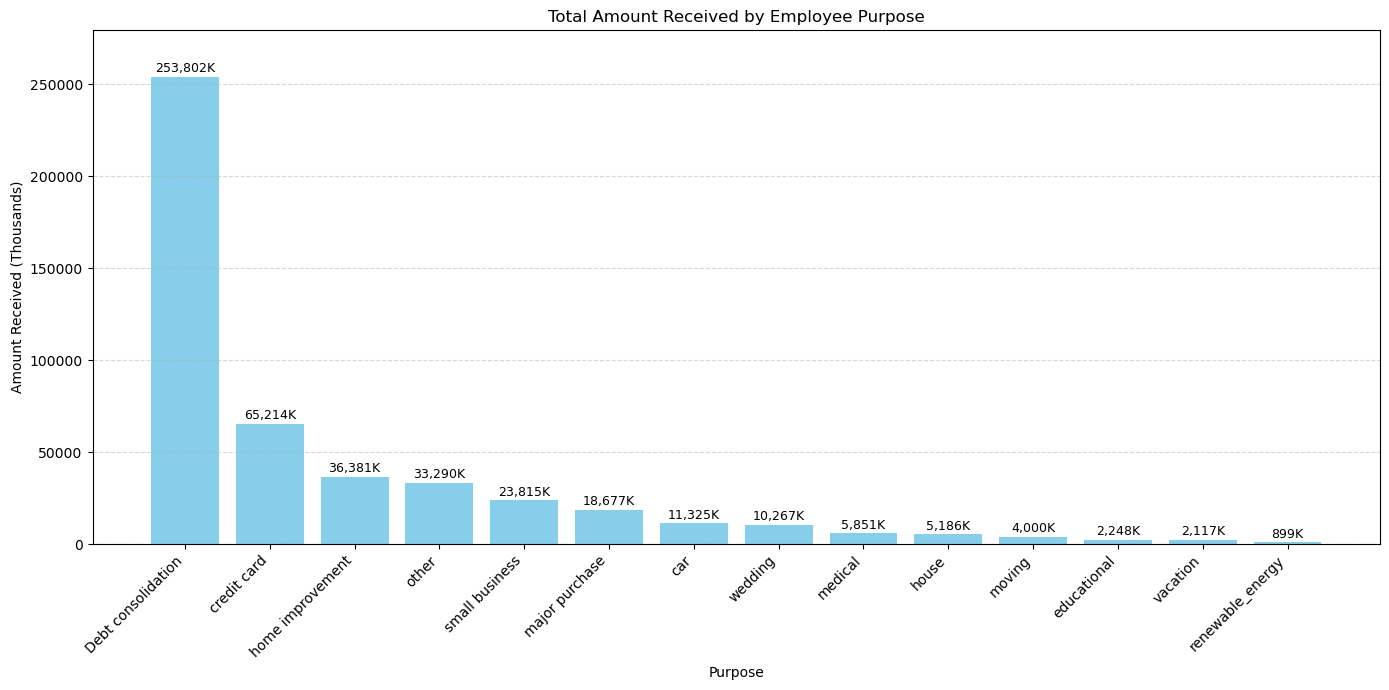

In [89]:
emp_Amt_Received = Bank_df.groupby('purpose')['total_payment'].sum().sort_values(ascending=False)/1000

plt.figure(figsize = (14,7))
bars = plt.bar(emp_Amt_Received.index, emp_Amt_Received.values, color ='Skyblue')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() /2, height + emp_Amt_Received.max() * 0.01,
            f"{height:,.0f}K", ha = 'center', fontsize = 9)

plt.title("Total Amount Received by Employee Purpose")
plt.xlabel("Purpose")
plt.ylabel("Amount Received (Thousands)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis = 'y', linestyle ='--', alpha = 0.5,)
plt.ylim(0, emp_Amt_Received.max() * 1.10)

plt.tight_layout()
plt.show()

### Employee purpose by Total loan Application

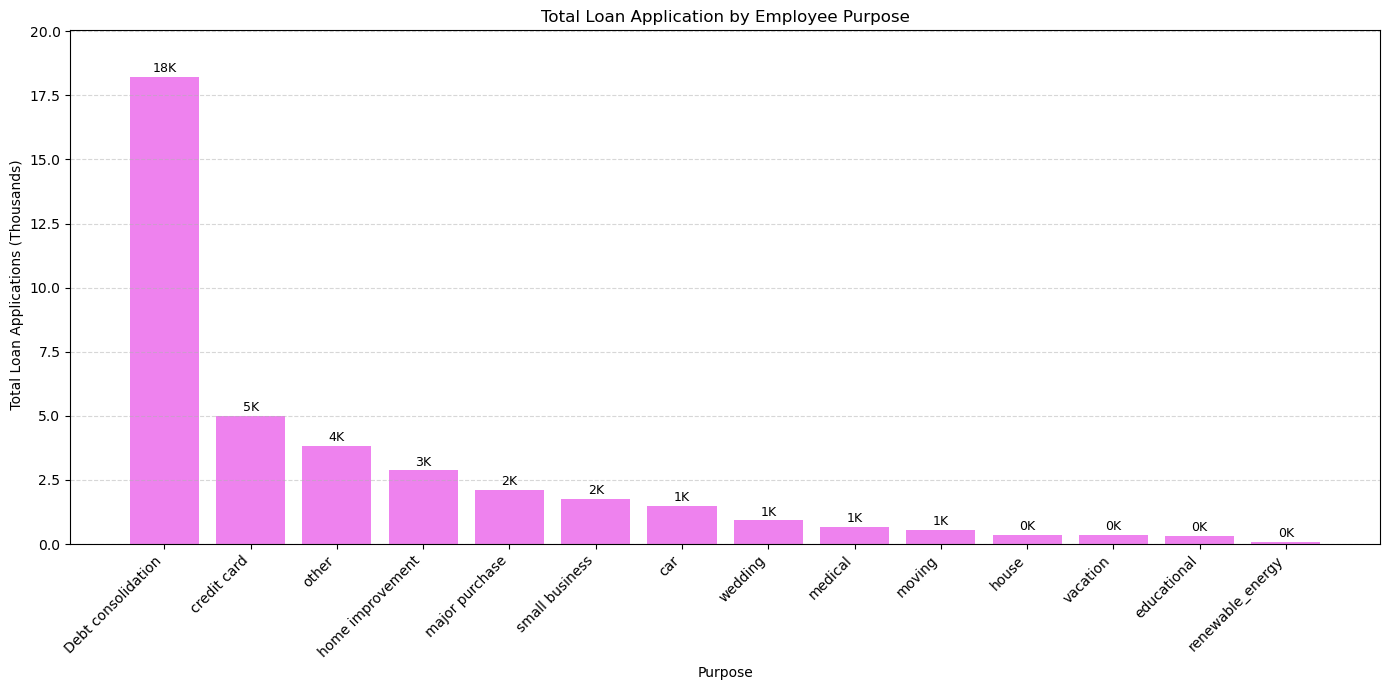

In [90]:
emp_loan_aaplication = Bank_df.groupby('purpose')['id'].count().sort_values(ascending=False)/1000

plt.figure(figsize = (14,7))
bars = plt.bar(emp_loan_aaplication.index, emp_loan_aaplication.values, color ='violet')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() /2, height + emp_loan_aaplication.max() * 0.01,
            f"{height:,.0f}K", ha = 'center', fontsize = 9)

plt.title("Total Loan Application by Employee Purpose")
plt.xlabel("Purpose")
plt.ylabel(" Total Loan Applications (Thousands)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis = 'y', linestyle ='--', alpha = 0.5,)
plt.ylim(0, emp_loan_aaplication.max() * 1.10)

plt.tight_layout()
plt.show()

## Home ownership by Total Funded Amount

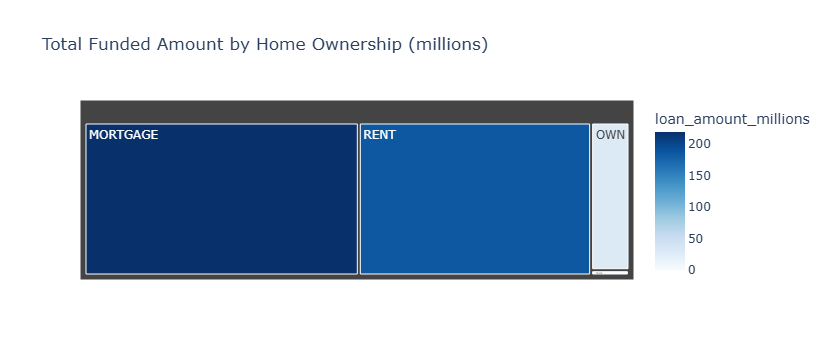

In [91]:
home_funding = Bank_df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path = ['home_ownership'],
    values = 'loan_amount_millions',
    color = 'loan_amount_millions',
    color_continuous_scale = 'Blues',
    title = 'Total Funded Amount by Home Ownership (millions)'
)

fig.show()

## Home ownership by Total Amount Received

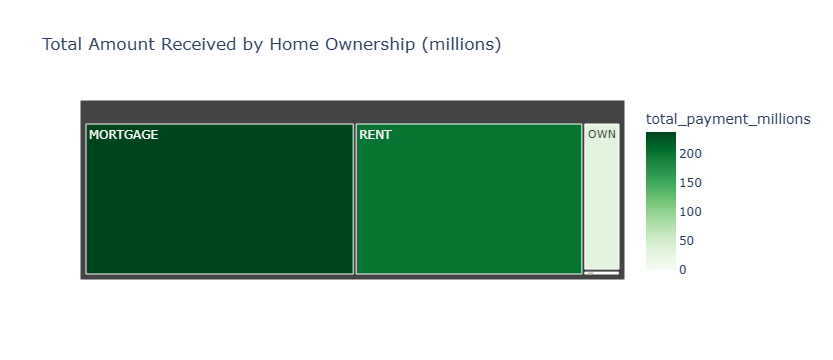

In [98]:
Amount_Received = Bank_df.groupby('home_ownership')['total_payment'].sum().reset_index()
Amount_Received['total_payment_millions'] = Amount_Received['total_payment'] / 1000000

fig = px.treemap(
    Amount_Received,
    path = ['home_ownership'],
    values = 'total_payment_millions',
    color = 'total_payment_millions',
    color_continuous_scale = 'greens',
    title = 'Total Amount Received by Home Ownership (millions)'
)

fig.show()

## Home ownership by Total loan application

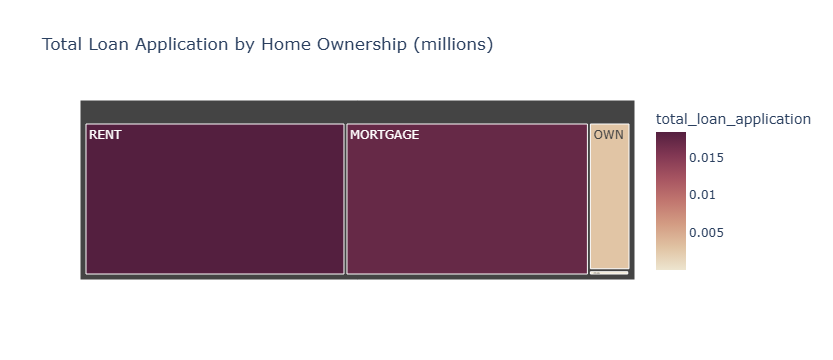

In [105]:
Loan_Application = Bank_df.groupby('home_ownership')['id'].count().reset_index()
Loan_Application['total_loan_application'] = Loan_Application['id'] / 1000000

fig = px.treemap(
    Loan_Application,
    path = ['home_ownership'],
    values = 'total_loan_application',
    color = 'total_loan_application',
    color_continuous_scale = 'Brwnyl',
    title = 'Total Loan Application by Home Ownership (millions)'
)

fig.show()

## Business Recommendations
* Focus on expanding loans in customer segments with high repayment rates and low default rates.
* Strengthen credit risk assessment to reduce bad loans and improve portfolio quality.
* Increase lending efforts in high-performing states while reviewing high-default regions.
* Optimize loan terms by promoting repayment-friendly loan durations.
* Monitor key KPIs regularly to support data-driven lending decisions and improve profitability.

### Exporting Clean Final Dataset.

After the analysis, we save the cleaned analytics table.
This file can be used for Power BI dashboard or further modeling.

In [109]:
# install Excel engine to save the file
!Pip install openpyxl

In [114]:
Bank_Loan_Analytics = "C:/Users/charp/OneDrive/Desktop/Data Analytics projects/Bank Loan Monitoring Project/Bank_Loan_Analytics.xlsx"

Bank_df.to_excel(Bank_Loan_Analytics, index=False)

print("Saved file:", Bank_Loan_Analytics)

Saved file: C:/Users/charp/OneDrive/Desktop/Data Analytics projects/Bank Loan Monitoring Project/Bank_Loan_Analytics.xlsx
